# Optimization TD 2 - Genetic algorithm

## Introduction

A genetic algorithm is a bio-inspired optimisation algorithm. It is inspired from the natural evolution of a set
of genes (a genome) to converge to an optimal mutation. Like all methods studied before, the goal is to find a
set of parameters minimizing the cost function. However, the approach is different because if it not based on
differential tools but instead is heuristic. The genetic algorithm is adapted in particular when the evaluation of
the cost function is indirect, and/or when the function is not differentiable, and/or when the set of parameters
is very large.
It is a simple algorithm to understand. We consider each parameter as a gene, and the set of gene is called the
genome of a given individual. Optimisation is with the following steps:
    
1. Build a initial population of genomes chosen randomly.
2. Population is evaluated : estimate the value of the cost function for each genome.
3. Genomes are sorted by cost. Those with the lower costs are selected. For every selected genome, a
mutation and/or a "crossing over" with another genome is performed.
4. A new population composed of the original selected genomes and their mutated version is created.
5. The new population is in turn evaluated and muted until convergence. The genome of the population which
minimizes the cost function is considered as a solution to the problem of optimization.

 ![alt text](pipeline.png)

## Exercice : Random walk

We will apply the genetic algorithm to a rather simple problem. We will modell a random march of dimension 1 on
T time steps, in direction d:
    
                                            x(t+1)=x(t)+d
    
with d a random number in {−1, 1}, and t={0, . . . , T−1}. The trajectory is intialized at 0, or x(0) = 0.
We wish to optimise the trajectory such that it stays in a given range [−r0 ; r0]. The cost of a trajectory will be
the number of steps outside of range [−r0 ; r0]. 
The following figure shows examples of random trajectory and optimized trajectory.

 <img src="genome_visualization.png" width="400"/> 

1. We define the genome of a trajectory as the vector of the values of d taken at times t={0, ... T-1}. Write a function which generates a random genome. It takes T (march length) as argument and returns a numpy array
of length T whose values are drawn randomly from {−1, 1}. Try your function with T=100 and print the result. From now, every function coded must be tested to prove it works as expected before going to the next question. 

In [1]:
import random
import numpy as np

In [2]:
# Random genome generation function
def randomgenome(T):
    r= np.random.choice([-1,1],T)
    return r

In [3]:
print(randomgenome(100))

[-1 -1 -1 -1 -1  1 -1 -1  1 -1  1 -1 -1 -1 -1  1  1 -1 -1  1  1  1  1  1
 -1 -1  1 -1  1 -1  1  1  1 -1  1  1 -1  1 -1 -1  1  1  1 -1 -1  1  1 -1
  1  1 -1 -1  1  1 -1 -1 -1 -1 -1  1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1
  1 -1 -1 -1 -1 -1  1  1  1 -1  1  1  1  1 -1 -1 -1  1  1  1 -1  1  1  1
 -1 -1 -1  1]


In [4]:
#Création d'un génome 
g = randomgenome(10)
print(g)

[-1  1  1 -1  1  1  1  1 -1  1]


2. Write the function that computes the cost of a genome. It takes in argument a genome and r0, the range.
It returns a scalar.

In [5]:
# Genome cost function
def cost_genome(genome,r0):
    cost=0
    trajectoire=0
    for i in range(len(genome)):
        trajectoire = trajectoire + genome[i]
        if (trajectoire > r0) | (trajectoire < -r0) : 
            cost= cost +1 
    return cost 


In [6]:
#Test du cout pour le génome g 
cout_g=cost_genome(g,1)
print(cout_g)

5


3. **Initialisation** : Write a function which creates an initial population of N genomes of length T and return it as a numpy array.

In [31]:
# Initialisation function
def create_pop(N,T): 
    population=[]
    for i in range(N):
        genome=randomgenome(T)
        population.append(genome)
    print("La population créee est:")
    print(np.array(population))
    print("")
    return np.array(population)


In [32]:
population_1= create_pop(6,10)

La population créee est:
[[-1 -1 -1  1 -1 -1 -1  1 -1 -1]
 [-1 -1  1 -1 -1  1  1  1  1 -1]
 [ 1 -1  1 -1 -1  1  1  1 -1  1]
 [-1  1 -1 -1  1 -1 -1  1 -1  1]
 [-1  1  1  1 -1  1  1  1  1  1]
 [-1 -1 -1 -1  1 -1 -1  1 -1  1]]



4. Write a function which returns the cost of all the genomes of a population as a numpy array.

In [33]:
# Population costs function
def population_cost(population,r0):
    cost_pop=[]
    for i in range (len(population)):
        genome_cost=cost_genome(population[i],r0)
        cost_pop.append(genome_cost)
    print("Le cout de chaque génome de la population est : ")
    print(cost_pop)
    print("")
    return cost_pop


In [34]:
population_cost(population_1,1)

Le cout de chaque génome de la population est : 
[9, 4, 2, 6, 6, 9]



[9, 4, 2, 6, 6, 9]

5. Write a function which sorts the genomes of a population by cost. *Hint* : use `numpy.argsort()`.

In [35]:
# Sort population function

def sort_population(population,r0): 
    print("La population non ordonnée est ")
    print(population)
    print("")
    
    #Création d'un tableau pour la population ordonnée 
    sorted_population=[]
    
    #Calcul du cout de la population non ordonnée 
    pop_cost=population_cost(population,r0)
    
    #Fonction argsort permettant de connaitre l'ordre dans lequel les génomes seront rangés par ordre croissant
    argsort=np.argsort(pop_cost)
    print(argsort)
    
   #Entrée des valeurs dans le bon ordre avec argsort[i] les indices permettant d'ordonner la population initiale
    for i in range(len(pop_cost)):
        sorted_population.append(population[argsort[i]])
    print("La population ordonnée est la suivante :")
    print(np.array(sorted_population))
    print("")
    
    return np.array(sorted_population)

In [36]:
sorted_population_1=sort_population(population_1,1)

La population non ordonnée est 
[[-1 -1 -1  1 -1 -1 -1  1 -1 -1]
 [-1 -1  1 -1 -1  1  1  1  1 -1]
 [ 1 -1  1 -1 -1  1  1  1 -1  1]
 [-1  1 -1 -1  1 -1 -1  1 -1  1]
 [-1  1  1  1 -1  1  1  1  1  1]
 [-1 -1 -1 -1  1 -1 -1  1 -1  1]]

Le cout de chaque génome de la population est : 
[9, 4, 2, 6, 6, 9]

[2 1 3 4 0 5]
La population ordonnée est la suivante :
[[ 1 -1  1 -1 -1  1  1  1 -1  1]
 [-1 -1  1 -1 -1  1  1  1  1 -1]
 [-1  1 -1 -1  1 -1 -1  1 -1  1]
 [-1  1  1  1 -1  1  1  1  1  1]
 [-1 -1 -1  1 -1 -1 -1  1 -1 -1]
 [-1 -1 -1 -1  1 -1 -1  1 -1  1]]



6. Write a function which selects and returns the Ns genomes having the lowest cost values. In this exercise, we will always set Ns = N/2 for simplicity. The output is the population to mute/cross! 

In [37]:
# Selection function of the LowestCostValues 
def selected_genomes(sorted_population):
    
    #La longueur de Ns est égale à la moitié de celle de N , on met int pour le cas ou N est impair 
    LenNs=int(len(sorted_population)/2)
    
    #Création de Ns 
    Ns=[]
    
    #Remplissage des valeurs 
    for i in range (LenNs):
        Ns.append(sorted_population[i])
    #Print valeurs et cout de ces dernières : 
    print("La population séléctionée avec le cout le plus faible est: ")
    print(np.array(Ns))
    print("Avec un cout de : ")
    print(population_cost(Ns,1)) #r0=1
    
    return np.array(Ns)


In [38]:
Ns_population_1=selected_genomes(sorted_population_1)

La population séléctionée avec le cout le plus faible est: 
[[ 1 -1  1 -1 -1  1  1  1 -1  1]
 [-1 -1  1 -1 -1  1  1  1  1 -1]
 [-1  1 -1 -1  1 -1 -1  1 -1  1]]
Avec un cout de : 
Le cout de chaque génome de la population est : 
[2, 4, 6]

[2, 4, 6]


7. **Mutation**: Genome mutation is defined by a rate Tm corresponding to the probability that a gene
has to mute. Write a function that browse over all genes of the genomes in the selected population and mute them with probability Tm. 

In [39]:
from random import random

In [40]:
# Mutation function
def mutation(population,Tm):
    
    #Print la population avant mutation: 
    print("La population avant mutation est :")
    print(population)
    print("")
    
    #Création d'une copie de la population 
    P=np.copy(population)
    
    for i in range (len(P)):
        for j in range (len(P[i])):
            a= random()
            if (a<Tm) :
                if (P[i][j]==1):
                    P[i][j]=-1
                elif (P[i][j]== -1):
                    P[i][j]=1
    print("La population après mutation est : ")
    print(P)
    print("")
    
    #Return la population mutée 
    return P
                


In [41]:
mutated_population_1=mutation(Ns_population_1,0.4)

La population avant mutation est :
[[ 1 -1  1 -1 -1  1  1  1 -1  1]
 [-1 -1  1 -1 -1  1  1  1  1 -1]
 [-1  1 -1 -1  1 -1 -1  1 -1  1]]

La population après mutation est : 
[[-1  1 -1 -1 -1 -1 -1  1  1  1]
 [-1 -1  1 -1  1 -1 -1 -1  1 -1]
 [-1  1 -1 -1 -1 -1 -1  1 -1 -1]]



8. We give the function below. Comment this function; what does it do to the population P? What is the biological meaning of this treatment? Rename it with an appropriate name.

In [42]:
# Mysterious function
from random import *

def crossing_over(P, Tc):
    new_P = np.copy(P)
    
    for i in range(0,len(new_P)):
        if random() < Tc:
            indc = randint(0, new_P.shape[0]-1) 
            posc = randint(0, new_P.shape[1]-1) 

            tmp = new_P[i,posc:new_P.shape[1]]
            new_P[i,posc:new_P.shape[1]] = new_P[indc,posc:new_P.shape[1]]
            new_P[indc,posc:new_P.shape[1]] = tmp
          
    return new_P 

9. **Algorithm loop** Create the main genetic algorithm code which will:
    - Initialize a population of size T
    
     for a number of generations n_gen :
        
    - Sort the population and select the Ns = N/2 best genomes
    - Apply mutations and other necessary treatments on the selected genomes
    - Create a new population by merging the selected genomes and the mutated genomes
    - Compute the mean cost and minimum cost of the new population
    
    Run the algorithm with T = 500 , r0 = 4 , N = 100 , Tm = 0.05 and Tc = 0.1. Draw the evolution of the mean and minimum cost as generations go by. Describe the algorithm's behavior

In [43]:
# Main loop
def genetic_algorithm(N,T,r0,Tm,Tc):
    
    #Création d'une population de taille (N,T)
    population=create_pop(N,T)
    
    #Taille de la moitié de la population qui sera séléctionnée: 
    LenNs= int(len(population)/2)
    
    #initialisation de n_gen soit la générations ou le nombre d'itérations:
    n_gen=0
    
    #Création de l'array gen qui contiendra les valeurs des générations:
    gen=[]
    
    #Création de l'array cout_moyen qui contiendra les valeurs des cout moyens
    cout_moyen=[]
    
    #Création de l'array pour le cout_minimal 
    cout_min=[]
    
    #Loop tant que l'algorithme n'a pas été effectué sur 500 générations ou 500 fois 
    while (n_gen<500): #500
        
        #On calcule le cout de chaque génome et on les ordonne grâce à la fonction suivante : 
        sorted_population=sort_population(population,r0)
        
        #On sélectionne la partie de la population de taille N/2 qui a le cout le plus faible à partir de la population ordonnée : 
        Ns=selected_genomes(sorted_population) # On la nomme Ns 
        
        #On calcule le cout de chaque génome de la population séléctionnée Ns: 
        cost_population=population_cost(Ns,r0)
        
        #On calcule la moyenne du cout des génome de la population
        mean_cost_population=np.mean(cost_population)
        
        #Print la moyenne avant les mutations/ crossing over
        print("Le cout moyen des génomes de la population séléctionnée avant les changements:")
        print(mean_cost_population)
        print("")
        
        #Mutation sur la population séléctionée 
        Ns_mutated=mutation(Ns,Tm)
        
        #Crossing over sur la population mutée Ns 
        Ns_mutated_and_crossed=crossing_over(Ns_mutated,Tc)
        
        #la population de départ est égale à la population de départ ordonnée
        population=sorted_population
        
        #Fusion de Ns_mutated_and_crossed avec sorted_population : On met Ns dans les N/2 premiières cases ayant le cout le plus faible 
        population[0:LenNs,:]= Ns_mutated_and_crossed
        
        #Calcul du cout de chaque génome de cette nouvelle population : soit cout après mutation/crossing over:
        final_cost=population_cost(population,r0)
        
        #Calcul de la moyenne des couts des génomes de la population: 
        mean_final_cost=np.mean(final_cost)
        
        #Calcul du cout minimum de la population : génome avec le cout le plus faible
        min_final_cost= np.amin(final_cost)
        
        #Print 
        print("Le nombre de génome dans la population est :",population.shape[0])
        print("")
        
        print("La moyenne du cout pour la population est de: ",mean_final_cost)
        print("")
        
        print("Le cout minimal de la population est de :",min_final_cost)
        print("")
        
        #Mise à jour des valeurs 
        n_gen= n_gen +1
        gen.append(n_gen)
        cout_moyen.append(mean_final_cost)
        cout_min.append(min_final_cost)
        
    return gen, cout_moyen, cout_min
    

In [44]:
import matplotlib 
import matplotlib.pyplot as plt 

In [45]:
N=100
T=500
r0=4
Tm=0.05
Tc=0.1

In [22]:
gen, cout_moyen, cout_min= genetic_algorithm(N,T,r0,Tm,Tc)

Text(0.5, 1.0, 'le cout moyen et minimal au cours des générations')

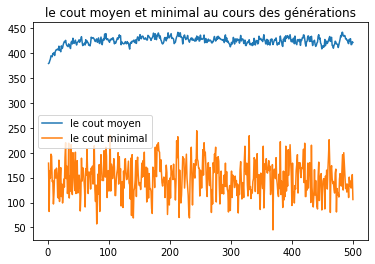

In [23]:
plt.plot(gen,cout_moyen, label='le cout moyen')
plt.plot(gen,cout_min, label='le cout minimal')
plt.legend()
plt.title('le cout moyen et minimal au cours des générations')

10. Think about an appropriate convergence criterion and implement it.

In [24]:
def convergence(N,T,r0,Tm,Tc):
    P=create_pop(N,T)
   
    #Initialise n_gen à 0 
    n_gen=0
    
    #Création de l'array gen pour stocker les valeurs de n_gen
    gen=[]
    
    #Création de l'array means pour stocker le cout moyen des génome de la population à chaque n_gen
    means=[]
    
    #Création de l'array mins pour stocker le cout minimal des génomes de la population à chaque n_gen
    mins=[]
    
    #Boucle 
    while n_gen<10: #Normalement n_gen < 250 si on veut voir un réel résultat mais problème d'exécution --> beaucoup trop long 
        
        #On ordonne la population P 
        S=sort_population(P,r0)
        
        #On fait des mutations puis des crossing_over sur la population S ordonnée 
        M=crossing_over(mutation(S,Tm),Tc)
        
        #La population P devient égale à S+M 
        P=np.vstack([S,M])
        
        #On calcul le cout de la population P 
        c=population_cost(P,r0)
        
        #On calcul la moyenne de tout les génomes  et on le rajoute dans means
        means.append(np.mean(c))
        
        #On cherche le min de chaque population et onle rajoute dans mins
        mins.append(np.min(c))
        
        #On met à jour les valeurs de n_gen et l'array gen contenant les valeurs 
        n_gen=n_gen+1
        
        gen.append(n_gen)
        
    #On plot les graphiques pour étudier la convergence    
    plt.plot(gen,means,label="Cout moyen")
    plt.plot(gen,mins,label="Cout minimum")
    plt.legend()
    
    return gen,means,mins



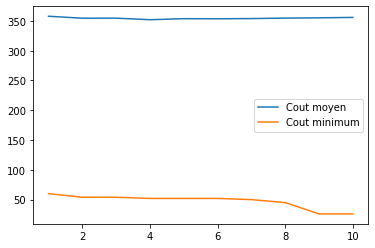

In [25]:
gen,means,mins=convergence(N,T,r0,Tm,Tc)

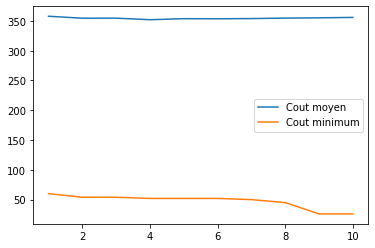

In [26]:
#Visualisation pour n_gen < 10 
plt.plot(gen,means,label="Cout moyen")
plt.plot(gen,mins,label="Cout minimum")
plt.legend()

11. Make the parameters (N, r0, Tm et Tc) vary to study their influence.

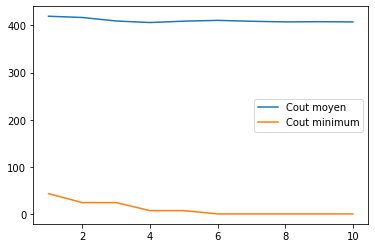

In [27]:
# Parameter variation
#Si on augmente les paramètres 
#Visualisation pour n_gen <10 
gen,means,mins=convergence(200,700,8,0.5,0.2)
#On remarque que ca converge moins rapidement même si l'on va que jusqu'à 10 au lieu d'aller jusqu'à 250 

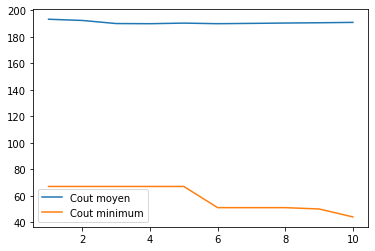

In [28]:
#Si on diminue les paramètres 
gen,means,mins= convergence(50,250,2,0.02,0.005) #pour n_gen <10
# Ca a l'air de converger plus rapidement mais comme n_gen petit nous ne pouvons pas être sur 

12. What differences can you see with differential methods such as gradient descent?

BONUS : Write a fonction to visualize the trajectory associated with a given a genome with `matplotlib`as in the introduction image. Displays one trajectory from different generations and comment on the evolution you observe.

In [29]:
# BONUS visualization function
def trajectoire(genome,r0): 
    #array pour stocker les valeurs de la trajectoire
    traj=[]
    #array pour stocker le pas 
    pas=[]
    #valeur t pour calculer la trajectoire initialiser à 0 
    t=0
    #Calcul de la trajectoire à partir du génome
    for i in range (len(genome)):
        t=t+genome[i]
        traj.append(t)
        pas.append(i)
    #Print des valeurs la trajectoire 
    print("La trajectoire est :")
    print(traj)
    
    #Print de la trajectoire 
    plt.plot(pas,traj)
    plt.plot([0.0, 10.0], [r0, r0], 'r-', lw=2) 
    plt.plot([0.0, 10.0], [-r0, -r0], 'r-', lw=2) 
    plt.title('Trajectoire associé au génome')
    #print(pas)
    #return traj,pas

La trajectoire est :
[-1, 0, 1, 0, 1, 2, 3, 4, 3, 4]


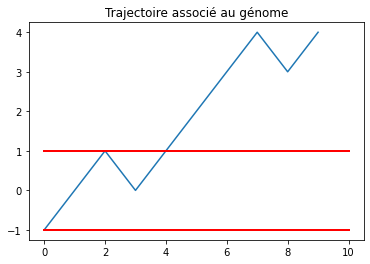

In [30]:
r0=1
trajectoire(g,r0)